# Analysis & Plotting Multimeric Inter XLs

### Setup

In [ ]:
#!/usr/bin/env python
# coding: utf-8

# # Analysis & Plotting Multimeric Inter XLs

import pandas as pd
import numpy as np
from pathlib import Path
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import sys

sys.path.insert(0, str(Path(__file__).resolve().parents[1]))
from config import REPO_ROOT, PROCESSED_DATA_DIR

# ── Load data ──────────────────────────────────────────────────────────────────

multimer_df = pd.read_csv(PROCESSED_DATA_DIR / '03_naive_multimer_inter_xl_calculations.csv')

null_multimer_df = pd.read_csv(PROCESSED_DATA_DIR / '04_naive_multimer_null_inter_xl_calculations.csv')

print(multimer_df.columns)
display(multimer_df.head())
display(null_multimer_df.head())

Index(['Is Decoy', 'Protein A', 'Protein B', 'Identification Score',
       'Identification DeltaScore', '# CSMs', '# Crosslinks',
       'Disambiguated Accessions A', 'Disambiguated Accessions B', 'Local FDR',
       'Crosslink Position A', 'Crosslink Position B', 'Crosslinked Residue A',
       'Crosslinked Residue B', 'distance_mean', 'distance_std',
       'distance_min', 'distance_max', 'intra_pae_protein_a_mean',
       'intra_pae_protein_b_mean', 'ipae_interface_min_mean_across_models',
       'iptm_mean', 'iptm_chai_default_mean', 'ipae_interface_mean_best_model',
       'ipae_interface_mean_best_model_idx', 'ipae_contact_mean_best_model',
       'ipae_contact_mean_best_model_idx',
       'ipae_contact_mean_best_model_distance', 'ipae_xl_site_best_model',
       'ipae_xl_site_best_model_idx', 'ipae_xl_site_best_model_distance',
       'ipae_xl_window_mean_best_model', 'ipae_xl_window_mean_best_model_idx',
       'ipae_xl_window_mean_best_model_distance',
       'ipae_xl_window_

,Is Decoy,Protein A,Protein B,Identification Score,Identification DeltaScore,# CSMs,# Crosslinks,Disambiguated Accessions A,Disambiguated Accessions B,Local FDR,...,model_4_distance,model_4_chains_swapped,model_4_ipae_interface_min,model_4_ipae_interface_mean,model_4_ipae_contact_mean,model_4_iptm,model_4_iptm_chai_default,model_4_ipae_xl_site,model_4_ipae_xl_window_mean,model_4_ipae_xl_window_median
0,False,TGRH88_000140,TGRH88_035710,77.53,39.20,1,1,NaN,TGRH88_000180;TGRH88_000160,1.492724e-02,...,35.323242,False,18.810131,28.418198,28.057182,0.096822,0.108949,28.312188,28.392862,28.271736
1,False,TGRH88_000140,TGRH88_047040,72.05,45.32,1,1,NaN,NaN,1.934681e-02,...,29.346565,False,21.496674,28.900456,28.208958,0.082734,0.105001,28.693775,28.363100,28.622795
2,False,TGRH88_000170,TGRH88_007680,112.75,85.96,1,1,TGRH88_000130;TGRH88_000150,NaN,2.530560e-04,...,53.669857,False,23.434063,29.377207,28.785133,0.094454,0.098966,29.074121,28.950937,29.021263
3,False,TGRH88_000170,TGRH88_013490,199.40,152.35,2,2,TGRH88_000130;TGRH88_000150;NA,NA;TGRH88_000130;TGRH88_000150,6.677860e-18,...,36.073597,False,21.378935,29.093134,28.440170,0.103960,0.107726,29.031437,28.698421,28.784786
4,False,TGRH88_000170,TGRH88_013490,199.40,152.35,2,2,TGRH88_000130;TGRH88_000150;NA,NA;TGRH88_000130;TGRH88_000150,6.677860e-18,...,36.929100,False,21.378935,29.093134,28.440170,0.103960,0.107726,28.784223,28.901033,28.985294


,Is Decoy,Protein A,Protein B,Identification Score,Identification DeltaScore,# CSMs,# Crosslinks,Disambiguated Accessions A,Disambiguated Accessions B,Local FDR,...,model_4_distance,model_4_chains_swapped,model_4_ipae_interface_min,model_4_ipae_interface_mean,model_4_ipae_contact_mean,model_4_iptm,model_4_iptm_chai_default,model_4_ipae_xl_site,model_4_ipae_xl_window_mean,model_4_ipae_xl_window_median
0,False,TGRH88_000140,TGRH88_035710,77.53,39.20,1,1,NaN,TGRH88_000180;TGRH88_000160,1.492724e-02,...,28.312771,False,18.810131,28.418198,28.057182,0.096822,0.108949,28.598355,28.329159,28.368807
1,False,TGRH88_000140,TGRH88_047040,72.05,45.32,1,1,NaN,NaN,1.934681e-02,...,89.734734,False,21.496674,28.900456,28.208958,0.082734,0.105001,29.609526,29.562429,29.533974
2,False,TGRH88_000170,TGRH88_007680,112.75,85.96,1,1,TGRH88_000130;TGRH88_000150,NaN,2.530560e-04,...,66.712753,False,23.434063,29.377207,28.785133,0.094454,0.098966,29.388441,29.096094,29.086639
3,False,TGRH88_000170,TGRH88_013490,199.40,152.35,2,2,TGRH88_000130;TGRH88_000150;NA,NA;TGRH88_000130;TGRH88_000150,6.677860e-18,...,33.632053,False,21.378935,29.093134,28.440170,0.103960,0.107726,28.739921,28.655458,28.331848
4,False,TGRH88_000170,TGRH88_035710,404.73,330.49,6,3,TGRH88_000130;TGRH88_000150;NA,NA;TGRH88_000150;TGRH88_000130,0.000000e+00,...,61.490826,True,12.785475,28.160662,26.732105,0.138292,0.145473,28.971690,28.731535,28.760883


### Multimer frequency plotted by iPTM and iPAE

In [37]:
# ── Column definitions ─────────────────────────────────────────────────────────

# Unique crosslink identity: protein pair + positions + residues
xl_key_cols = [
    "Protein A",
    "Protein B",
    "Crosslink Position A",
    "Crosslink Position B",
    "Crosslinked Residue A",
    "Crosslinked Residue B",
]

model_dist_cols = [f"model_{i}_distance" for i in range(5)]

pae_bin_labels = ["<15", ">15"]
pae_bins       = [0, 15, np.inf]

# ── Preprocessing ──────────────────────────────────────────────────────────────

def preprocess(df):
    """
    Return (unique_xl_df, unique_pair_df) from a raw multimer-style dataframe.

    unique_xl_df   — one row per unique crosslink (protein pair + positions)
    unique_pair_df — one row per protein pair (the crosslink with the lowest
                     iPAE_XL_window_mean_best_model for that pair)
    """
    # Unique crosslinks
    xl = df.drop_duplicates(subset=xl_key_cols).copy()

    # Per protein-pair: keep the row with the lowest iPAE_XL_window_mean_best_model
    pair = (
        df.sort_values("ipae_xl_window_mean_best_model", na_position="last")
          .groupby(["Protein A", "Protein B"], as_index=False)
          .first()
    )

    for frame in (xl, pair):
        n_models = frame[model_dist_cols].notna().sum(axis=1)
        frame["frac_models_lt_35A"] = (
            (frame[model_dist_cols] < 35.0).sum(axis=1)
            / n_models.replace(0, np.nan)
        )
        frame["pae_mean_bin"] = pd.cut(
            frame["ipae_xl_window_mean_best_model"],
            bins=pae_bins,
            labels=pae_bin_labels,
            right=False,
            include_lowest=True,
        )
        frame["n_models_satisfied"] = (
            (frame[model_dist_cols] < 35.0).sum(axis=1).astype(int)
        )

    return xl, pair


unique_xl_df,   unique_pair_df   = preprocess(multimer_df)
null_xl_df,     null_pair_df     = preprocess(null_multimer_df)

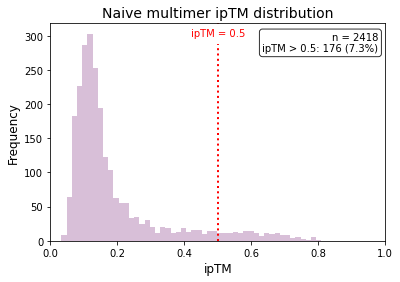

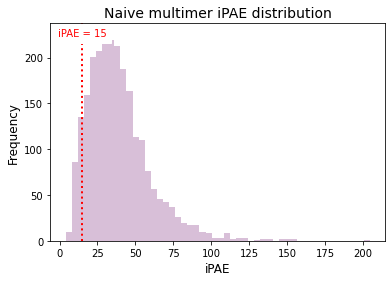

In [51]:
#plot frequency by ipTM (mean iPTM)
iptm_values = unique_pair_df['iptm_mean'].dropna()
n_total = len(iptm_values)
n_above_05 = (iptm_values > 0.5).sum()
pct_above_05 = 100 * n_above_05 / n_total if n_total > 0 else 0

plt.hist(iptm_values, bins=50, color='thistle')
plt.axvline(x=0.5, linestyle='dotted', linewidth=2, color='red')
# Add centered "pTM = 0.5" label above the red line
ylim = plt.ylim()
ypos = ylim[1] * 0.93  # 93% up the y-axis
plt.text(
    0.5, ypos, 'ipTM = 0.5', color='red', ha='center', va='bottom', fontsize=10, backgroundcolor='white'
)

plt.xlabel('ipTM', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Naive multimer ipTM distribution', fontsize=14)
plt.xlim(0, 1.0)  # Set x-axis maximum value to 1.0
plt.xticks(np.arange(0, 1.01, 0.2))  # Set x-ticks every 0.2 increment

# Add n and percentage annotation in upper right inside the plot
plt.text(
    0.98, 0.96 * ylim[1],
    f'n = {n_total}\n'
    f'ipTM > 0.5: {n_above_05} ({pct_above_05:.1f}%)',
    ha='right', va='top', fontsize=10, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round')
)

plt.show()

#plot frequency by PAE (PAE of the same model with xl_window_pae_mean_best_model)
plt.hist(unique_pair_df['ipae_xl_window_mean_best_model_distance'], bins=50, color='thistle')
plt.axvline(x=15, linestyle='dotted', linewidth=2, color='red')
# Add centered "pTM = 0.5" label above the red line
ylim = plt.ylim()
ypos = ylim[1] * 0.93  # 93% up the y-axis
plt.text(
    15, ypos, 'iPAE = 15', color='red', ha='center', va='bottom', fontsize=10, backgroundcolor='white'
)
plt.xlabel('iPAE', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Naive multimer iPAE distribution', fontsize=14)
plt.show()

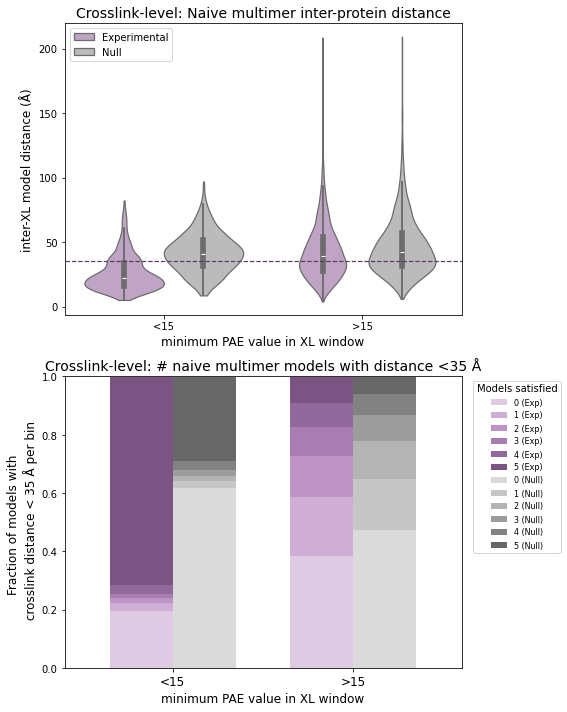

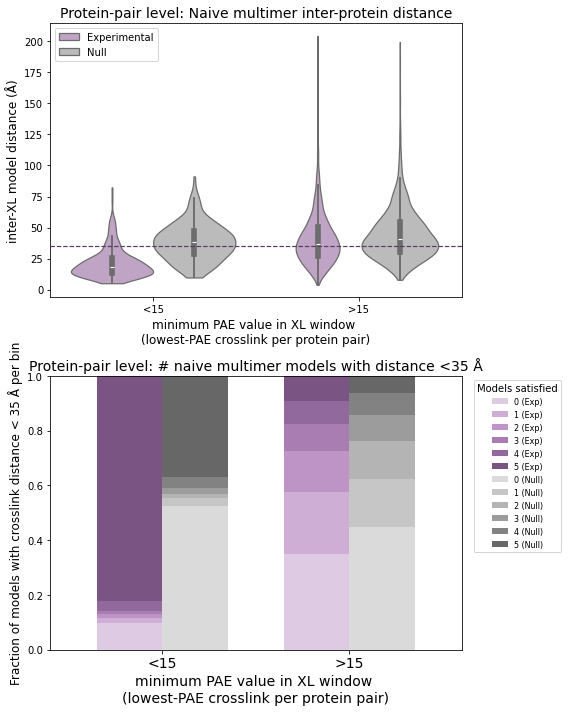

Average number of crosslinks per protein pair: 3.18

unique_xl_df:   7,698 rows  |  null_xl_df:   5,222 rows
unique_pair_df: 2,420 rows  |  null_pair_df: 2,420 rows
  (unique_pair_df = one row per protein pair)


In [46]:
# ### Plot 1: Crosslink-centric plot of multimeric PAE and inter-protein distance agreement


# ── Color palettes ─────────────────────────────────────────────────────────────

BASE_PURPLE = "blend:#FFFFFF,#B586BE,#4B2E57"
BASE_GRAY   = "blend:#FFFFFF,#AAAAAA,#333333"

_purples = sns.color_palette(BASE_PURPLE, 16)
_grays   = sns.color_palette(BASE_GRAY,   16)

purple_line = _purples[-2]

def make_palette(base, n):
    pal = sns.color_palette(base, max(n + 4, 8))
    return pal[2 : 2 + n]

# ── Helpers ────────────────────────────────────────────────────────────────────

def combine(exp_df, null_df, cols):
    """Tag experimental vs null and concatenate."""
    e = exp_df.dropna(subset=cols).copy(); e["source"] = "Experimental"
    n = null_df.dropna(subset=cols).copy(); n["source"] = "Null"
    return pd.concat([e, n], ignore_index=True)

def make_crosstab(df, bin_labels, n_sat):
    ct = pd.crosstab(df["pae_mean_bin"], df["n_models_satisfied"], normalize="index")
    return (
        ct.reindex(bin_labels, fill_value=0)
          .reindex(columns=n_sat, fill_value=0)
    )

DIST_COLS = ["pae_mean_bin", "ipae_xl_window_mean_best_model_distance"]
FRAC_COLS = ["pae_mean_bin", "frac_models_lt_35A", "n_models_satisfied"]


# ══════════════════════════════════════════════════════════════════════════════
#  FIGURE 1 — Crosslink-level
# ══════════════════════════════════════════════════════════════════════════════

plot_xl_both      = combine(unique_xl_df, null_xl_df, DIST_COLS)
plot_xl_frac_both = combine(unique_xl_df, null_xl_df, FRAC_COLS)

fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# Violin: distance by PAE bin -------------------------------------------------
sns.violinplot(
    data=plot_xl_both,
    x="pae_mean_bin",
    y="ipae_xl_window_mean_best_model_distance",
    hue="source",
    hue_order=["Experimental", "Null"],
    order=pae_bin_labels,
    ax=axes[0],
    inner="box",
    cut=0,
    palette={"Experimental": _purples[6], "Null": _grays[6]},
)
axes[0].axhline(35, color=purple_line, linestyle="--", linewidth=1.2, zorder=10)
axes[0].set_xlabel("minimum PAE value in XL window", fontsize=12)
axes[0].set_ylabel("inter-XL model distance (Å)", fontsize=12)
axes[0].set_title("Crosslink-level: Naive multimer inter-protein distance", fontsize=14)

# Modify: Remove legend title & place inside upper left (loc='upper left', no bbox_to_anchor)
legend_0 = axes[0].legend(title=None, loc="upper left")
# If you want to further condense spacing inside, you can use frameon=True/False
# legend_0.set_frame_on(False)

# Stacked bars: models satisfied by PAE bin -----------------------------------
xl_frac_exp  = plot_xl_frac_both[plot_xl_frac_both["source"] == "Experimental"]
xl_frac_null = plot_xl_frac_both[plot_xl_frac_both["source"] == "Null"]

n_sat_xl   = np.arange(0, int(plot_xl_frac_both["n_models_satisfied"].max()) + 1)
ct_xl_exp  = make_crosstab(xl_frac_exp,  pae_bin_labels, n_sat_xl)
ct_xl_null = make_crosstab(xl_frac_null, pae_bin_labels, n_sat_xl)
purple_cols = make_palette(BASE_PURPLE, len(n_sat_xl))
gray_cols   = make_palette(BASE_GRAY,   len(n_sat_xl))

ct_xl_exp.plot( kind="bar", stacked=True, ax=axes[1], width=0.35,
                color=purple_cols, legend=False, position=1)
ct_xl_null.plot(kind="bar", stacked=True, ax=axes[1], width=0.35,
                color=gray_cols,   legend=False, position=0)

axes[1].legend(
    handles=(
        [Patch(facecolor=purple_cols[i], label=f"{i} (Exp)")  for i in n_sat_xl] +
        [Patch(facecolor=gray_cols[i],   label=f"{i} (Null)") for i in n_sat_xl]
    ),
    title="Models satisfied", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8,
)
axes[1].set_xticks(range(len(pae_bin_labels)))
axes[1].set_xticklabels(pae_bin_labels, rotation=0, fontsize=12)
axes[1].set_xlabel("minimum PAE value in XL window", fontsize=12)
axes[1].set_ylabel("Fraction of models with \n crosslink distance < 35 Å per bin", fontsize=12)
axes[1].set_title("Crosslink-level: # naive multimer models with distance <35 Å", fontsize=14)
axes[1].set_ylim(0, 1)

# After both ct_xl_exp.plot(...) and ct_xl_null.plot(...), etc.
ax_bar = axes[1]              # whichever axis has the stacked bars
x_left, x_right = ax_bar.get_xlim()
pad = 0.35                    # tune: larger = more gap
ax_bar.set_xlim(x_left - pad, x_right)

ax_bar = axes2[1]
x_left, x_right = ax_bar.get_xlim()
pad = 0.35
ax_bar.set_xlim(x_left - pad, x_right)

plt.tight_layout()
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
#  FIGURE 2 — Protein-pair level
# ══════════════════════════════════════════════════════════════════════════════

plot_pair_both      = combine(unique_pair_df, null_pair_df, DIST_COLS)
plot_pair_frac_both = combine(unique_pair_df, null_pair_df, FRAC_COLS)

fig2, axes2 = plt.subplots(2, 1, figsize=(8, 10))

PAIR_XLABEL = "minimum PAE value in XL window \n(lowest-PAE crosslink per protein pair)"

# Violin: distance by PAE bin -------------------------------------------------
sns.violinplot(
    data=plot_pair_both,
    x="pae_mean_bin",
    y="ipae_xl_window_mean_best_model_distance",
    hue="source",
    hue_order=["Experimental", "Null"],
    order=pae_bin_labels,
    ax=axes2[0],
    inner="box",
    cut=0,
    palette={"Experimental": _purples[6], "Null": _grays[6]},
)
axes2[0].axhline(35, color=purple_line, linestyle="--", linewidth=1.2, zorder=10)
axes2[0].set_xlabel(PAIR_XLABEL, fontsize=12)
axes2[0].set_ylabel("inter-XL model distance (Å)", fontsize=12)
axes2[0].set_title("Protein-pair level: Naive multimer inter-protein distance", fontsize=14)

# Modify: Remove legend title & place inside upper left for violin plot legend
legend_2_0 = axes2[0].legend(title=None, loc="upper left")

# Stacked bars: models satisfied by PAE bin -----------------------------------
pair_frac_exp  = plot_pair_frac_both[plot_pair_frac_both["source"] == "Experimental"]
pair_frac_null = plot_pair_frac_both[plot_pair_frac_both["source"] == "Null"]

n_sat_pair      = np.arange(0, int(plot_pair_frac_both["n_models_satisfied"].max()) + 1)
ct_pair_exp     = make_crosstab(pair_frac_exp,  pae_bin_labels, n_sat_pair)
ct_pair_null    = make_crosstab(pair_frac_null, pae_bin_labels, n_sat_pair)
purple_cols_p   = make_palette(BASE_PURPLE, len(n_sat_pair))
gray_cols_p     = make_palette(BASE_GRAY,   len(n_sat_pair))

ct_pair_exp.plot( kind="bar", stacked=True, ax=axes2[1], width=0.35,
                  color=purple_cols_p, legend=False, position=1)
ct_pair_null.plot(kind="bar", stacked=True, ax=axes2[1], width=0.35,
                  color=gray_cols_p,   legend=False, position=0)

axes2[1].legend(
    handles=(
        [Patch(facecolor=purple_cols_p[i], label=f"{i} (Exp)")  for i in n_sat_pair] +
        [Patch(facecolor=gray_cols_p[i],   label=f"{i} (Null)") for i in n_sat_pair]
    ),
    title="Models satisfied", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8,
)
axes2[1].set_xticks(range(len(pae_bin_labels)))
axes2[1].set_xticklabels(pae_bin_labels, rotation=0, fontsize=14)
axes2[1].set_xlabel(PAIR_XLABEL, fontsize=14)
axes2[1].set_ylabel("Fraction of models with crosslink distance < 35 Å per bin", fontsize=12)
axes2[1].set_title("Protein-pair level: # naive multimer models with distance <35 Å", fontsize=14)
axes2[1].set_ylim(0, 1)

# After both ct_xl_exp.plot(...) and ct_xl_null.plot(...), etc.
ax_bar = axes[1]              # whichever axis has the stacked bars
x_left, x_right = ax_bar.get_xlim()
pad = 0.35                    # tune: larger = more gap
ax_bar.set_xlim(x_left - pad, x_right)

ax_bar = axes2[1]
x_left, x_right = ax_bar.get_xlim()
pad = 0.35
ax_bar.set_xlim(x_left - pad, x_right)

plt.tight_layout()
plt.show()


# ── Summary statistics ─────────────────────────────────────────────────────────

avg_xl_per_pair = unique_xl_df.groupby(["Protein A", "Protein B"]).size().mean()
print(f"Average number of crosslinks per protein pair: {avg_xl_per_pair:.2f}")

print(f"\nunique_xl_df:   {len(unique_xl_df):,} rows  |  null_xl_df:   {len(null_xl_df):,} rows")
print(f"unique_pair_df: {len(unique_pair_df):,} rows  |  null_pair_df: {len(null_pair_df):,} rows")
print(f"  (unique_pair_df = one row per protein pair)")